Setup listo. Semilla fija: 42
Found 143 PDF files in raw directory.


Extracting PDF text: 100%|██████████| 143/143 [02:01<00:00,  1.18it/s]



Successfully extracted text from 143 PDFs.
Raw data saved to: /Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_raw.csv
Computing extended raw text metrics...

=== RAW CORPUS OVERALL SUMMARY ===
Total Documents: 143
Total Raw Words (Tokens): 535,709
Total Characters: 3,809,735
Average Words per Document: 3746.22 (Std: 5645.99)
Average Lexical Diversity (Raw TTR): 0.3697

=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===
                               mean           std        min           50%  \
word_count              3746.216783   5645.991148  11.000000   2170.000000   
char_count             26641.503497  38888.869984  71.000000  16048.000000   
line_count               381.909091    552.485433   2.000000    232.000000   
unique_word_count       1074.727273    979.390204  11.000000    842.000000   
avg_word_length            7.117404      0.439699   6.201940      7.106764   
lexical_diversity_ttr    

/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


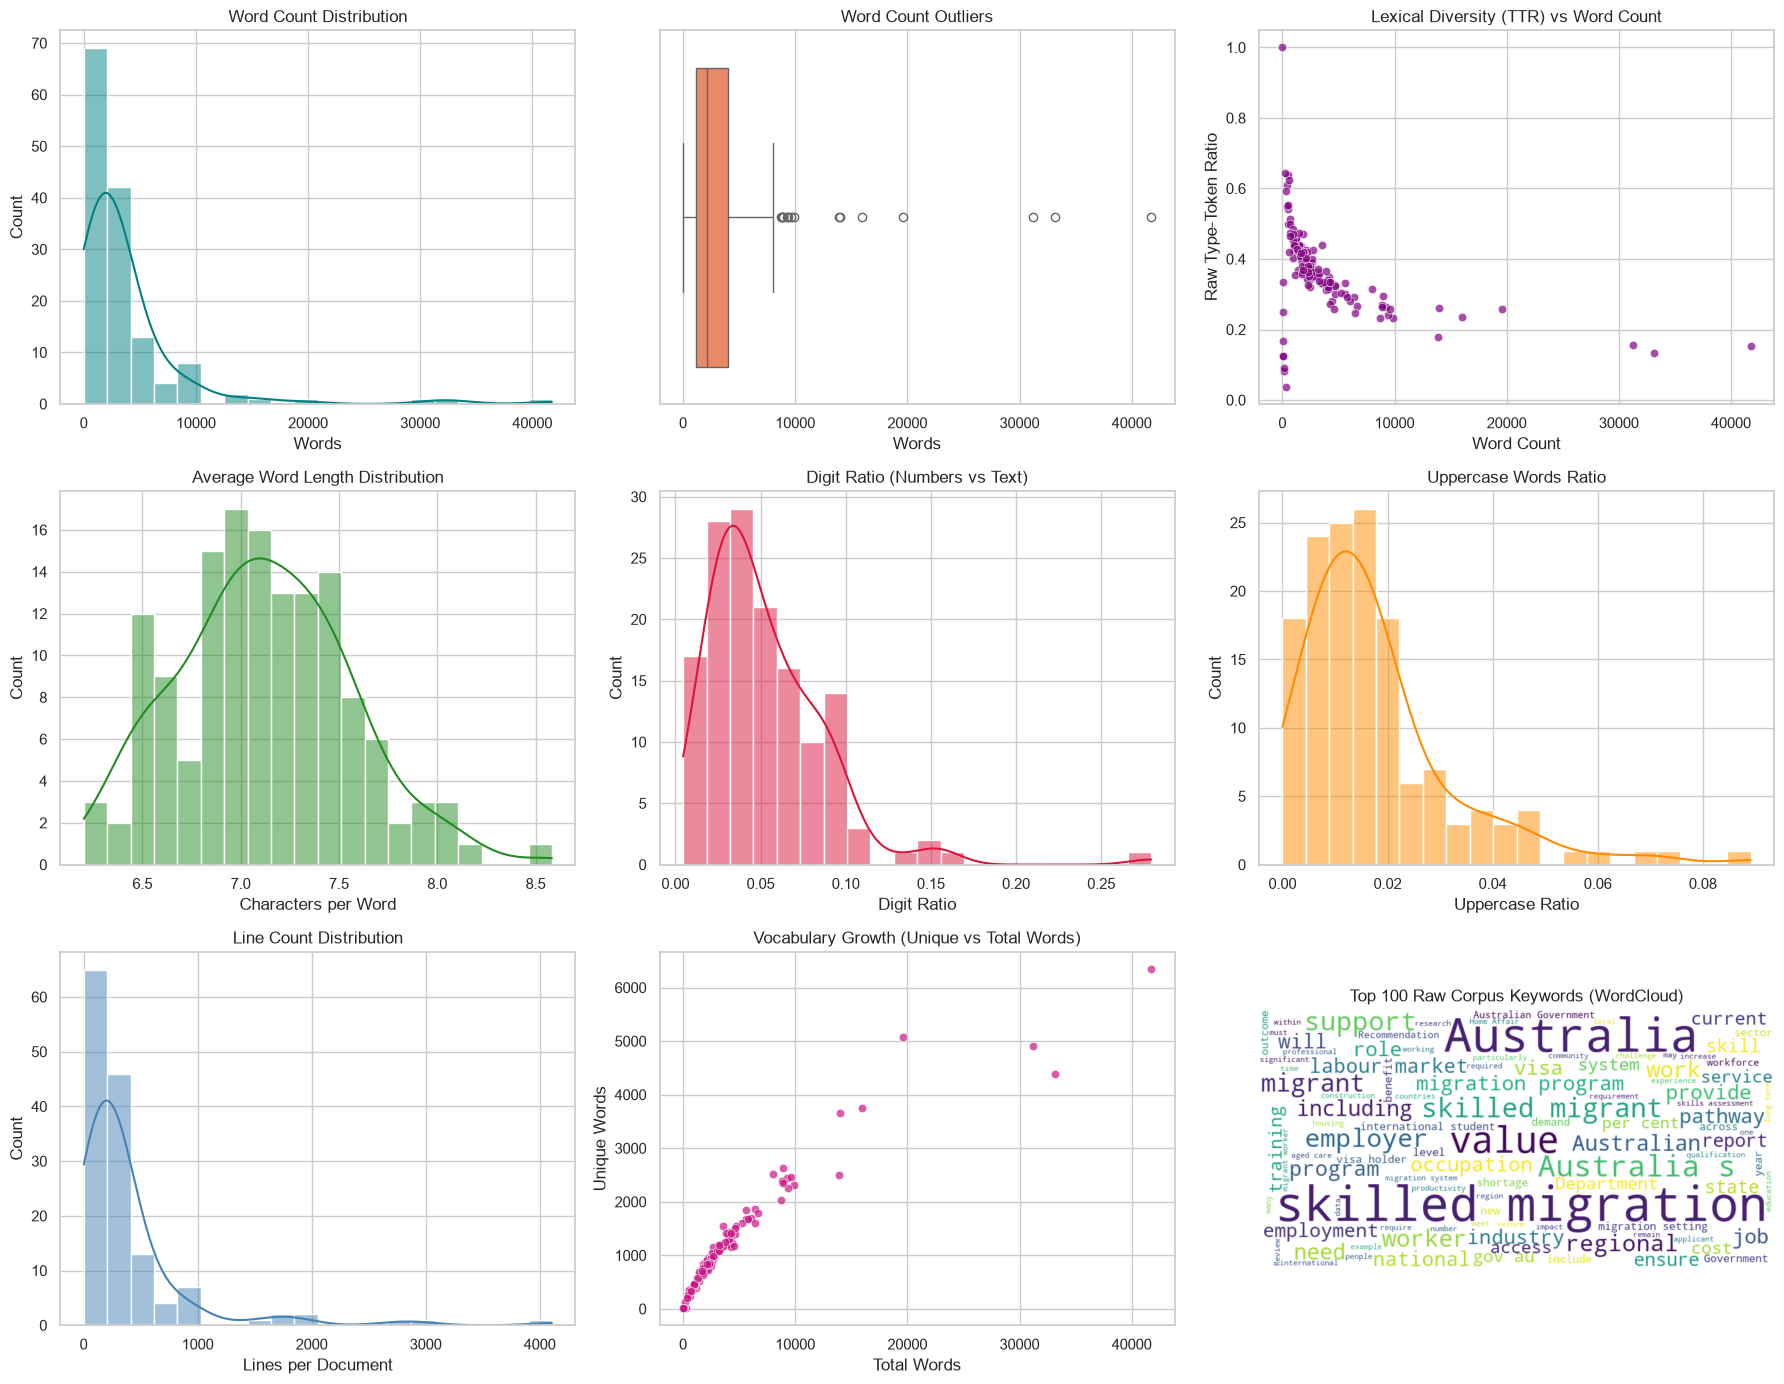

Boilerplate lines detected (appear in >=30% of docs): 1
  - inquiry into the value of skilled migration to australia

Average % of words removed by boilerplate stripping: 9.94%
(Debería ser un porcentaje pequeño, 1-8%. Si es mucho más alto, el umbral min_doc_fraction es muy laxo.)
Cleaning and lemmatizing text corpus...


Cleaning: 100%|██████████| 143/143 [00:15<00:00,  9.26it/s]


Text preprocessing complete!
CHECKPOINT 1: TEXT CLEANING QUALITY
Average % of words removed during cleaning: 43.46%
If this is above ~70-75%, the cleaning may be too aggressive.

--- Sample raw vs. clean text (first 2 documents) ---

[Document 0] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 106
Inquiry into the value of skilled migration to Australia
Submission 106
Who we are
The Federation of Ethnic Communities’ Council

[Document 0] CLEAN (first 200 chars):
federation ethnic community council fecca national peak body represent people culturally linguistically diverse cald community organisation across membership state territory regional ethnic community 

[Document 1] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 112
Inquiry into the value of
Skilled Migration to
Australia
Submission by the Australian Council of Trade Unions
ACTU Submission, D

[Document 1] CLEAN (first 200 chars):
value skille

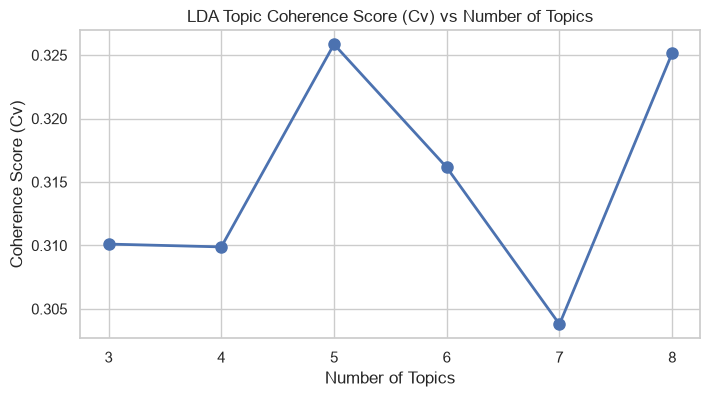


Optimal number of topics selected: 5 (Cv = 0.3259)

=== TOP 10 KEYWORDS PER TOPIC (LDA - 5 TOPICS) ===

Topic 1:
 -> health, nurse, social, age_care, care, assessment, aasw, practice, barrier, healthcare

Topic 2:
 -> immigration, applicant, temporary, application, permanent, review, research, department_home_affair, labour_market, talent

Topic 3:
 -> construction, trade, overseas, application, temporary, per_cent, subclass_visa, skill_assessment, person, train

Topic 4:
 -> temporary, condition, palm_scheme, international_student, palm_worker, exploitation, university, right, scheme, reform

Topic 5:
 -> south, international_student, refugee, permanent, reform, state, trade, underutilisation, student, temporary
CHECKPOINT 5: TOPIC QUALITY AND DISTRIBUTION
Read the topic keywords above. Do they look like coherent, real-world
concepts? Or generic words like 'would', 'also', 'one', 'said'?
If you see generic filler words dominating a topic, add them to
custom_stopwords in step 4 and re


Final processed dataset saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_processed.csv


In [1]:
# %% [markdown]
# # Skilled Migration Submissions — Topic Modeling Pipeline (LDA)
#
# Pipeline completo: extracción de PDFs -> estadísticas del texto crudo ->
# limpieza (con corrección de boilerplate, apóstrofes y lematización POS-aware)
# -> detección de bigramas/trigramas -> filtrado de documentos ->
# diccionario/corpus -> entrenamiento LDA con búsqueda de num_topics ->
# visualización -> validación humana.
#
# Cada bloque grande imprime un CHECKPOINT para que puedas revisar la calidad
# de ese paso antes de seguir al siguiente.

# %%
# ======================================================================
# 0. IMPORTS, SEEDS Y RUTAS
# ======================================================================
import json
import os
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import pdfplumber

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from IPython.display import HTML, display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import gensim
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel, Phrases
from gensim.models.phrases import Phraser
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# --- Reproducibilidad ---
# Fijamos semillas en todos los generadores relevantes para que las
# corridas sean comparables entre sí (evita el problema que tuvimos antes
# de números de coherencia "iguales por coincidencia" o "distintos sin razón").
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Rutas ---
RAW_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/raw"
)
PROCESSED_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed"
)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# --- Descarga de recursos NLTK necesarios (incluye el POS tagger, que antes faltaba) ---
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                  "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass  # algunos nombres de recurso varían según la versión de nltk; no es crítico si uno falla

print("Setup listo. Semilla fija:", SEED)

# %%
# ======================================================================
# 1. EXTRACCIÓN DE TEXTO DESDE LOS PDFs
# ======================================================================
def extract_pdf_text(filepath):
    """Extrae texto plano de un PDF usando pdfplumber."""
    full_text = []
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text.append(text)
        return "\n".join(full_text)
    except Exception as e:
        print(f"Error reading {filepath.name}: {e}")
        return None


pdf_files = list(RAW_DATA_PATH.glob("*.[pP][dD][fF]"))
print(f"Found {len(pdf_files)} PDF files in raw directory.")

records = []
for pdf_path in tqdm(pdf_files, desc="Extracting PDF text"):
    content = extract_pdf_text(pdf_path)
    if content:
        records.append({
            "archivo": pdf_path.name,
            "tamano_bytes": pdf_path.stat().st_size,
            "texto_raw": content,
        })

df = pd.DataFrame(records)
print(f"\nSuccessfully extracted text from {len(df)} PDFs.")

raw_csv_path = PROCESSED_DATA_PATH / "submissions_raw.csv"
df.to_csv(raw_csv_path, index=False)
print(f"Raw data saved to: {raw_csv_path}")

# %%
# ======================================================================
# 2. ESTADÍSTICAS Y VISUALIZACIÓN DEL TEXTO CRUDO
# ======================================================================
print("Computing extended raw text metrics...")

df["char_count"] = df["texto_raw"].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df["word_count"] = df["texto_raw"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df["line_count"] = df["texto_raw"].apply(lambda x: len(str(x).splitlines()) if pd.notna(x) else 0)

df["unique_word_count"] = df["texto_raw"].apply(
    lambda x: len(set(str(x).lower().split())) if pd.notna(x) else 0
)
df["avg_word_length"] = df.apply(
    lambda row: row["char_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)
df["lexical_diversity_ttr"] = df.apply(
    lambda row: row["unique_word_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)

df["uppercase_word_count"] = df["texto_raw"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]) if pd.notna(x) else 0
)
df["digit_count"] = df["texto_raw"].apply(lambda x: len(re.findall(r"\d+", str(x))) if pd.notna(x) else 0)
df["punctuation_count"] = df["texto_raw"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x))) if pd.notna(x) else 0
)

df["digit_ratio"] = df["digit_count"] / df["word_count"].replace(0, 1)
df["uppercase_ratio"] = df["uppercase_word_count"] / df["word_count"].replace(0, 1)

print("\n=== RAW CORPUS OVERALL SUMMARY ===")
print(f"Total Documents: {len(df):,}")
print(f"Total Raw Words (Tokens): {df['word_count'].sum():,}")
print(f"Total Characters: {df['char_count'].sum():,}")
print(f"Average Words per Document: {df['word_count'].mean():.2f} (Std: {df['word_count'].std():.2f})")
print(f"Average Lexical Diversity (Raw TTR): {df['lexical_diversity_ttr'].mean():.4f}")

print("\n=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===")
metrics_to_show = [
    "word_count", "char_count", "line_count", "unique_word_count",
    "avg_word_length", "lexical_diversity_ttr", "digit_ratio", "uppercase_ratio",
]
print(df[metrics_to_show].describe().T[["mean", "std", "min", "50%", "max"]])

print("\n=== EXTREME DOCUMENTS IDENTIFICATION (solo diagnóstico, el filtro real se aplica más adelante) ===")
short_docs = df[df["word_count"] < 100][["archivo", "word_count", "char_count"]]
print(f"Documents with fewer than 100 words: {len(short_docs)}")
if len(short_docs) > 0:
    print(short_docs.head())

high_digit_docs = df[df["digit_ratio"] > 0.1][["archivo", "word_count", "digit_ratio"]]
print(f"\nDocuments with >10% digits (potential data tables): {len(high_digit_docs)}")
if len(high_digit_docs) > 0:
    print(high_digit_docs.head())

# --- Visualización 3x3 ---
print("\nGenerating extended visualization panel including WordCloud...")
all_text = " ".join(df["texto_raw"].dropna().tolist())
custom_wc_stopwords = set(STOPWORDS).union({
    "http", "https", "www", "com", "pdf", "page", "subclass", "submission",
    "inquiry", "committee",
})

wc = WordCloud(
    width=800, height=400, background_color="white",
    stopwords=custom_wc_stopwords, max_words=100, colormap="viridis", random_state=SEED,
).generate(all_text)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.histplot(df["word_count"], kde=True, ax=axes[0, 0], color="teal", bins=20)
axes[0, 0].set_title("Word Count Distribution")
axes[0, 0].set_xlabel("Words")

sns.boxplot(x=df["word_count"], ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Word Count Outliers")
axes[0, 1].set_xlabel("Words")

sns.scatterplot(data=df, x="word_count", y="lexical_diversity_ttr", ax=axes[0, 2], alpha=0.7, color="purple")
axes[0, 2].set_title("Lexical Diversity (TTR) vs Word Count")
axes[0, 2].set_xlabel("Word Count")
axes[0, 2].set_ylabel("Raw Type-Token Ratio")

sns.histplot(df["avg_word_length"], kde=True, ax=axes[1, 0], color="forestgreen", bins=20)
axes[1, 0].set_title("Average Word Length Distribution")
axes[1, 0].set_xlabel("Characters per Word")

sns.histplot(df["digit_ratio"], kde=True, ax=axes[1, 1], color="crimson", bins=20)
axes[1, 1].set_title("Digit Ratio (Numbers vs Text)")
axes[1, 1].set_xlabel("Digit Ratio")

sns.histplot(df["uppercase_ratio"], kde=True, ax=axes[1, 2], color="darkorange", bins=20)
axes[1, 2].set_title("Uppercase Words Ratio")
axes[1, 2].set_xlabel("Uppercase Ratio")

sns.histplot(df["line_count"], kde=True, ax=axes[2, 0], color="steelblue", bins=20)
axes[2, 0].set_title("Line Count Distribution")
axes[2, 0].set_xlabel("Lines per Document")

sns.scatterplot(data=df, x="word_count", y="unique_word_count", ax=axes[2, 1], color="mediumvioletred", alpha=0.7)
axes[2, 1].set_title("Vocabulary Growth (Unique vs Total Words)")
axes[2, 1].set_xlabel("Total Words")
axes[2, 1].set_ylabel("Unique Words")

axes[2, 2].imshow(wc, interpolation="bilinear")
axes[2, 2].axis("off")
axes[2, 2].set_title("Top 100 Raw Corpus Keywords (WordCloud)")

plt.tight_layout()
plt.show()

# %%
# ======================================================================
# 3. ELIMINACIÓN DE BOILERPLATE (títulos/encabezados repetidos)
# ======================================================================
# Problema detectado: el título del "Inquiry" y palabras como "Submission N"
# se repiten 2-3 veces en la mayoría de los documentos (portada + encabezado).
# Esto infla artificialmente esas palabras y genera bigramas falsos como
# "value_skilled_migration". Aquí detectamos líneas que se repiten en muchos
# documentos y las quitamos ANTES de limpiar el texto. Es un enfoque genérico:
# funciona para cualquier corpus con encabezados/pies de página repetidos, no
# solo para este dataset en particular.

def normalize_line(line):
    return re.sub(r"\s+", " ", line.strip().lower())


def find_boilerplate_lines(texts, min_doc_fraction=0.3, min_len=15):
    """Encuentra líneas (normalizadas) que aparecen en >= min_doc_fraction
    de los documentos. Esas líneas son casi siempre encabezados, pies de
    página o títulos repetidos, no contenido real."""
    line_doc_counts = Counter()
    n_docs = len(texts)
    for text in texts:
        if not isinstance(text, str):
            continue
        lines = {normalize_line(l) for l in text.splitlines() if len(l.strip()) >= min_len}
        for line in lines:
            line_doc_counts[line] += 1
    threshold = max(2, int(n_docs * min_doc_fraction))
    boilerplate = {line for line, count in line_doc_counts.items() if count >= threshold}
    return boilerplate


def remove_boilerplate(text, boilerplate_set):
    if not isinstance(text, str):
        return text
    kept_lines = [l for l in text.splitlines() if normalize_line(l) not in boilerplate_set]
    return "\n".join(kept_lines)


boilerplate_lines = find_boilerplate_lines(df["texto_raw"].tolist(), min_doc_fraction=0.3)
print(f"Boilerplate lines detected (appear in >=30% of docs): {len(boilerplate_lines)}")
for line in list(boilerplate_lines)[:10]:
    print("  -", line[:100])

df["texto_sin_boilerplate"] = df["texto_raw"].apply(lambda x: remove_boilerplate(x, boilerplate_lines))

# También quitamos números de submission sueltos tipo "Submission 106" que a
# veces no caen en una línea completa detectada arriba.
df["texto_sin_boilerplate"] = df["texto_sin_boilerplate"].apply(
    lambda x: re.sub(r"\bsubmission\s*\d+\b", " ", str(x), flags=re.IGNORECASE) if pd.notna(x) else x
)

removed_word_pct = (
    (df["texto_raw"].str.split().str.len() - df["texto_sin_boilerplate"].str.split().str.len())
    / df["texto_raw"].str.split().str.len().replace(0, 1)
) * 100
print(f"\nAverage % of words removed by boilerplate stripping: {removed_word_pct.mean():.2f}%")
print("(Debería ser un porcentaje pequeño, 1-8%. Si es mucho más alto, el umbral min_doc_fraction es muy laxo.)")

# %%
# ======================================================================
# 4. LIMPIEZA Y LEMATIZACIÓN (con fixes: contracciones, POS tagging, stopwords completas)
# ======================================================================
stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "sub", "submission", "inquiry", "committee", "australia", "australian",
    "parliament", "parliamentary", "page", "pdf", "accordance", "attached",
    "http", "https", "www", "com",  # <-- antes solo estaban en el wordcloud, no aquí
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

# Mini diccionario de contracciones comunes en inglés (evita el bug de
# "don't" -> "don t" -> token fantasma "don").
CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am",
}


def expand_contractions(text):
    text = text.replace("’", "'")  # normaliza apóstrofe curvo a recto
    for pattern, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(pattern) + r"\b", expansion, text)
    return text


def get_wordnet_pos(treebank_tag):
    """Convierte los tags de NLTK POS a los que espera WordNetLemmatizer,
    para que verbos y adjetivos se lematicen correctamente (no solo sustantivos)."""
    if treebank_tag.startswith("J"):
        return "a"  # adjective
    elif treebank_tag.startswith("V"):
        return "v"  # verb
    elif treebank_tag.startswith("R"):
        return "r"  # adverb
    else:
        return "n"  # noun (default)


def preprocess_and_lemmatize(text):
    """
    Limpia texto crudo (ya sin boilerplate):
    - Expande contracciones (evita el bug del apóstrofe)
    - Minúsculas
    - Quita números, puntuación y símbolos no alfabéticos
    - Tokeniza
    - Lematiza usando POS tagging real (verbos, adjetivos, sustantivos)
    - Quita stopwords y tokens de longitud <= 2
    """
    if not isinstance(text, str):
        return ""

    text = expand_contractions(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    clean_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(clean_tokens)


print("Cleaning and lemmatizing text corpus...")
tqdm.pandas(desc="Cleaning")
df["texto_limpio"] = df["texto_sin_boilerplate"].progress_apply(preprocess_and_lemmatize)
print("Text preprocessing complete!")

df["clean_word_count"] = df["texto_limpio"].apply(lambda x: len(x.split()))
df["words_removed_%"] = ((df["word_count"] - df["clean_word_count"]) / df["word_count"]) * 100

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 1: CALIDAD DE LA LIMPIEZA
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 1: TEXT CLEANING QUALITY")
print("=" * 70)
print(f"Average % of words removed during cleaning: {df['words_removed_%'].mean():.2f}%")
print("If this is above ~70-75%, the cleaning may be too aggressive.\n")

print("--- Sample raw vs. clean text (first 2 documents) ---")
for i in range(min(2, len(df))):
    print(f"\n[Document {i}] RAW (first 200 chars):")
    print(str(df["texto_raw"].iloc[i])[:200])
    print(f"\n[Document {i}] CLEAN (first 200 chars):")
    print(str(df["texto_limpio"].iloc[i])[:200])

all_words = " ".join(df["texto_limpio"].dropna()).split()
word_freq = pd.Series(Counter(all_words)).sort_values(ascending=False)
print("\n--- Top 50 most frequent words after cleaning ---")
print(word_freq.head(50))

ghost_tokens = [w for w in set(all_words) if w in {"don", "isn", "wasn", "aren", "doesn", "didn", "hasn", "wouldn"}]
print(f"\nGhost tokens still present (should be empty): {ghost_tokens}")

http_leftovers = [w for w in set(all_words) if w in {"http", "https", "www", "com"}]
print(f"URL-related leftovers (should be empty): {http_leftovers}")

# %%
# ======================================================================
# 5. DETECCIÓN DE BIGRAMAS Y TRIGRAMAS (gensim Phrases, con umbral estricto)
# ======================================================================
# min_count: la frase debe aparecer al menos N veces en todo el corpus.
# threshold: más alto = más estricto = menos frases, pero de mejor calidad.
# Solo aplicamos el modelo de frases 2 veces (bigramas, luego trigramas sobre
# el resultado) para evitar cadenas larguísimas tipo "public_awareness_understanding_role".
tokens_list_raw = [doc.split() for doc in df["texto_limpio"].dropna()]

bigram_model = Phrases(tokens_list_raw, min_count=5, threshold=15)
bigram_phraser = Phraser(bigram_model)

trigram_model = Phrases(bigram_phraser[tokens_list_raw], min_count=5, threshold=15)
trigram_phraser = Phraser(trigram_model)

tokens_list = [trigram_phraser[bigram_phraser[doc]] for doc in tokens_list_raw]

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 2: CALIDAD DE BIGRAMAS/TRIGRAMAS
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 2: BIGRAM / TRIGRAM QUALITY")
print("=" * 70)

all_tokens_flat = [tok for doc in tokens_list for tok in doc]
phrase_freq = pd.Series(Counter(t for t in all_tokens_flat if "_" in t)).sort_values(ascending=False)
print("--- Top 20 detected phrases ---")
print(phrase_freq.head(20))

# Alerta si hay frases artificialmente largas (4+ palabras pegadas)
long_chains = [p for p in phrase_freq.index if p.count("_") >= 3]
print(f"\nPhrases with 4+ words chained together (usually a red flag): {len(long_chains)}")
if long_chains:
    print(long_chains[:10])

print("\nRead through this list: phrases should look like real concepts")
print("(e.g. 'skill_shortage'), not generic grammar combos or long chains.")

# %%
# ======================================================================
# 6. FILTRADO DE DOCUMENTOS (criterios separados: cortos vs. ruidosos)
# ======================================================================
# Antes: cualquier documento con digit_ratio > 0.1 se descartaba, lo cual
# eliminaba documentos LARGOS y con mucho contenido real solo porque tenían
# tablas o referencias numeradas. Ahora separamos dos criterios:
#   (a) demasiado corto para aportar señal temática (< 50 palabras limpias)
#   (b) dominado por números/tablas de verdad (digit_ratio muy alto, > 0.25)
# y solo filtramos si se cumple alguno de esos dos, no un umbral laxo genérico.

MIN_CLEAN_WORDS = 50
MAX_DIGIT_RATIO = 0.25

df["is_too_short"] = df["clean_word_count"] < MIN_CLEAN_WORDS
df["is_too_numeric"] = df["digit_ratio"] > MAX_DIGIT_RATIO

mask_keep = ~(df["is_too_short"] | df["is_too_numeric"])

print("=" * 70)
print("CHECKPOINT 3: DOCUMENT FILTERING")
print("=" * 70)
print(f"Documents before filtering: {len(df)}")
print(f"Documents removed for being too short (<{MIN_CLEAN_WORDS} clean words): {df['is_too_short'].sum()}")
print(f"Documents removed for being too numeric (digit_ratio > {MAX_DIGIT_RATIO}): {df['is_too_numeric'].sum()}")
print(f"Documents after filtering: {mask_keep.sum()}")
print("If you removed more than ~20% of the corpus, double check that the")
print("removed documents are actually low-quality and not legitimate texts.\n")

removed_docs = df[~mask_keep][["archivo", "word_count", "clean_word_count", "digit_ratio"]]
print("--- Sample of removed documents ---")
print(removed_docs.head(10))

df_filtered = df[mask_keep].reset_index(drop=True)
tokens_list = [tokens_list[i] for i in range(len(tokens_list)) if mask_keep.iloc[i]]

# %%
# ======================================================================
# 7. DICCIONARIO Y CORPUS PARA GENSIM
# ======================================================================
print("Preparing dictionary and corpus for LDA...")

dictionary = corpora.Dictionary(tokens_list)
# no_above más estricto que el original (0.85 -> 0.6): saca palabras que
# aparecen en más del 60% de los documentos y no ayudan a diferenciar tópicos.
dictionary.filter_extremes(no_below=3, no_above=0.6)

corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

print(f"Dictionary Size (Unique Tokens): {len(dictionary)}")
print(f"Total Processed Documents: {len(corpus)}")

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 4: CALIDAD DEL DICCIONARIO
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 4: DICTIONARY QUALITY")
print("=" * 70)
print(f"Dictionary size: {len(dictionary)} unique tokens for {len(corpus)} documents")
print("As a rule of thumb, for ~100-150 documents, a healthy dictionary")
print("size is usually in the 500-2000 range. Much higher suggests the")
print("cleaning/filtering upstream still needs tightening.\n")

sample_size = min(30, len(dictionary))
sample_words = random.sample(list(dictionary.token2id.keys()), sample_size)
print(f"--- Random sample of {sample_size} dictionary words ---")
print(sample_words)
print("\nCheck: do these look like real, meaningful words/phrases?")
print("If you see fragments, garbage, or long chained phrases, revisit steps 4-5.")

# %%
# ======================================================================
# 8. ENTRENAMIENTO LDA + BÚSQUEDA DE NÚMERO ÓPTIMO DE TÓPICOS
# ======================================================================
print("\nEvaluating LDA Topic Coherence Scores (Cv)...")
topic_range = range(3, 9)
coherence_scores = []
lda_models = {}

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=SEED,
        passes=15,
        iterations=400,   # antes no se especificaba (default 50); ayuda a que
                           # el modelo converja mejor con alpha/eta 'auto'
        alpha="auto",
        eta="auto",
    )
    coherence_model = CoherenceModel(
        model=lda_model, texts=tokens_list, dictionary=dictionary, coherence="c_v"
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    lda_models[num_topics] = lda_model
    print(f"Topics: {num_topics} -> Coherence Score (Cv): {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(topic_range), coherence_scores, "bo-", linewidth=2, markersize=8)
plt.title("LDA Topic Coherence Score (Cv) vs Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (Cv)")
plt.grid(True)
plt.show()

optimal_num_topics = list(topic_range)[np.argmax(coherence_scores)]
best_lda_model = lda_models[optimal_num_topics]
print(f"\nOptimal number of topics selected: {optimal_num_topics} (Cv = {max(coherence_scores):.4f})")

print(f"\n=== TOP 10 KEYWORDS PER TOPIC (LDA - {optimal_num_topics} TOPICS) ===")
for topic_id in range(optimal_num_topics):
    terms = best_lda_model.show_topic(topic_id, topn=10)
    words = [word for word, weight in terms]
    print(f"\nTopic {topic_id + 1}:")
    print(" -> " + ", ".join(words))

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 5: CALIDAD Y DISTRIBUCIÓN DE TÓPICOS
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 5: TOPIC QUALITY AND DISTRIBUTION")
print("=" * 70)
print("Read the topic keywords above. Do they look like coherent, real-world")
print("concepts? Or generic words like 'would', 'also', 'one', 'said'?")
print("If you see generic filler words dominating a topic, add them to")
print("custom_stopwords in step 4 and re-run from there.\n")

dominant_topics = []
for bow in corpus:
    topic_probs = best_lda_model.get_document_topics(bow)
    dominant = max(topic_probs, key=lambda x: x[1])[0] if topic_probs else -1
    dominant_topics.append(dominant)

df_filtered["dominant_topic"] = dominant_topics

topic_distribution = df_filtered["dominant_topic"].value_counts().sort_index()
print("--- Number of documents per dominant topic ---")
print(topic_distribution)
print("\nIf one topic absorbs the vast majority of documents, the model")
print("likely isn't finding meaningful structure (try fewer topics, or")
print("revisit the cleaning/filtering/phrase-detection steps).")

# %%
# ----------------------------------------------------------------------
# CHECKPOINT 6: VALIDACIÓN HUMANA
# ----------------------------------------------------------------------
print("=" * 70)
print("CHECKPOINT 6: HUMAN VALIDATION SAMPLE")
print("=" * 70)
print("Read these documents and judge whether the assigned topic makes sense.\n")

sample_docs = df_filtered.sample(min(5, len(df_filtered)), random_state=SEED)
for _, row in sample_docs.iterrows():
    print(f"\nDocument: {row['archivo']}")
    print(f"Assigned dominant topic: {row['dominant_topic'] + 1}")
    print(f"Raw text preview: {str(row['texto_raw'])[:200]}...")

# %%
# ======================================================================
# 9. VISUALIZACIÓN INTERACTIVA (pyLDAvis)
# ======================================================================
print("\nGenerating interactive pyLDAvis visualization...")

vis_data = gensimvis.prepare(best_lda_model, corpus, dictionary, sort_topics=False)


def clean_for_json(obj):
    if isinstance(obj, (np.complex128, np.complex64, complex)):
        return float(obj.real)
    if isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, pd.DataFrame):
        return obj.map(clean_for_json)
    if isinstance(obj, pd.Series):
        return obj.map(clean_for_json)
    return obj


cleaned_vis_data = pyLDAvis.PreparedData(
    topic_coordinates=clean_for_json(vis_data.topic_coordinates),
    topic_info=clean_for_json(vis_data.topic_info),
    token_table=clean_for_json(vis_data.token_table),
    R=vis_data.R,
    lambda_step=vis_data.lambda_step,
    plot_opts=vis_data.plot_opts,
    topic_order=vis_data.topic_order,
)

html_string = pyLDAvis.prepared_data_to_html(cleaned_vis_data)

css_override = """
<style>
    circle.bubble {
        fill-opacity: 0.6 !important;
        stroke: #333 !important;
        stroke-width: 1px !important;
    }
    circle.bubble:hover {
        fill-opacity: 0.9 !important;
        stroke-width: 2px !important;
    }
</style>
"""
html_string_fixed = css_override + html_string

html_output_path = PROCESSED_DATA_PATH / "lda_visualization.html"
with open(html_output_path, "w", encoding="utf-8") as f:
    f.write(html_string_fixed)

print(f"Interactive LDA visualization saved successfully at:\n{html_output_path}")
display(HTML(html_string_fixed))

# %%
# ======================================================================
# 10. GUARDAR DATASET PROCESADO
# ======================================================================
processed_csv_path = PROCESSED_DATA_PATH / "submissions_processed.csv"
df_filtered.to_csv(processed_csv_path, index=False)
print(f"\nFinal processed dataset saved successfully at:\n{processed_csv_path}")